In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("../data/processed/creditcard_processed.csv")

print("Dataset shape:")
print(df.shape)

print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape:
(283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (226980, 30)
Test set: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
model = GradientBoostingClassifier(
    random_state=42
)

print("Training Gradient Boosting model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Training Gradient Boosting model...
Model training completed!


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
print("First 20 fraud probabilities:")
print(y_prob[:20])

First 20 fraud probabilities:
[0.00021563 0.00021563 0.00052836 0.00021563 0.00021563 0.00021563
 0.00021563 0.00021563 0.00021563 0.00021563 0.00021563 0.00021563
 0.00021563 0.00021563 0.00021563 0.00021563 0.00021563 0.00021563
 0.00021563 0.00021563]


In [ ]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.6234


In [ ]:
def evaluate_threshold(y_true, y_prob, threshold):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    alerts = int(y_pred.sum())

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "alerts": alerts,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [ ]:
default_result = evaluate_threshold(
    y_test,
    y_prob,
    0.5
)

print(default_result)

{'threshold': 0.5, 'precision': 0.8611111111111112, 'recall': 0.6526315789473685, 'f1': 0.7425149700598802, 'alerts': 72, 'TN': np.int64(56641), 'FP': np.int64(10), 'FN': np.int64(33), 'TP': np.int64(62)}


In [ ]:
thresholds = np.arange(
    0.01,
    1.00,
    0.01
)
results = []

for threshold in thresholds:

    result = evaluate_threshold(
        y_test,
        y_prob,
        threshold
    )

    results.append(result)

In [ ]:
threshold_results = pd.DataFrame(results)

threshold_results.head()

,threshold,precision,recall,f1,alerts,TN,FP,FN,TP
0,0.01,0.516393,0.663158,0.580645,122,56592,59,32,63
1,0.02,0.552632,0.663158,0.602871,114,56600,51,32,63
2,0.03,0.600000,0.663158,0.630000,105,56609,42,32,63
3,0.04,0.605769,0.663158,0.633166,104,56610,41,32,63
4,0.05,0.623762,0.663158,0.642857,101,56613,38,32,63


In [ ]:
threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1,alerts,TN,FP,FN,TP
61,0.62,0.898551,0.652632,0.756098,69,56644,7,33,62
60,0.61,0.898551,0.652632,0.756098,69,56644,7,33,62
59,0.60,0.898551,0.652632,0.756098,69,56644,7,33,62
67,0.68,0.898551,0.652632,0.756098,69,56644,7,33,62
68,0.69,0.898551,0.652632,0.756098,69,56644,7,33,62
69,0.70,0.898551,0.652632,0.756098,69,56644,7,33,62
70,0.71,0.898551,0.652632,0.756098,69,56644,7,33,62
71,0.72,0.898551,0.652632,0.756098,69,56644,7,33,62
57,0.58,0.898551,0.652632,0.756098,69,56644,7,33,62
56,0.57,0.898551,0.652632,0.756098,69,56644,7,33,62


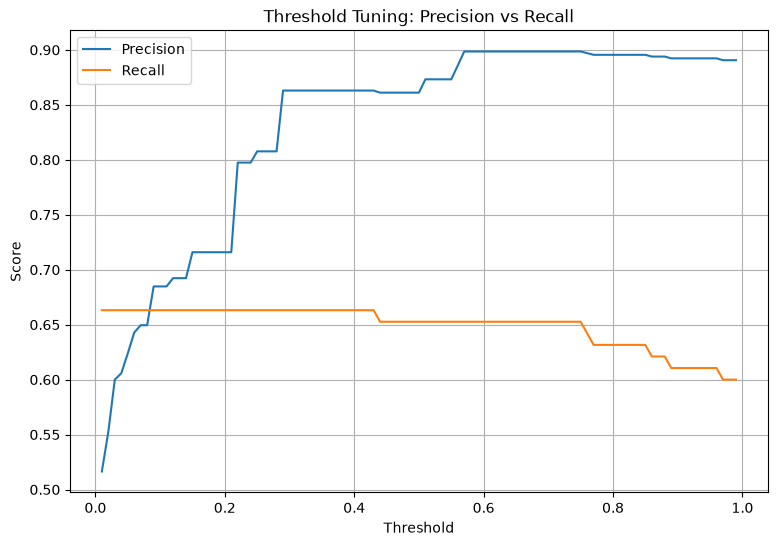

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning: Precision vs Recall")

plt.legend()
plt.grid()

plt.show()

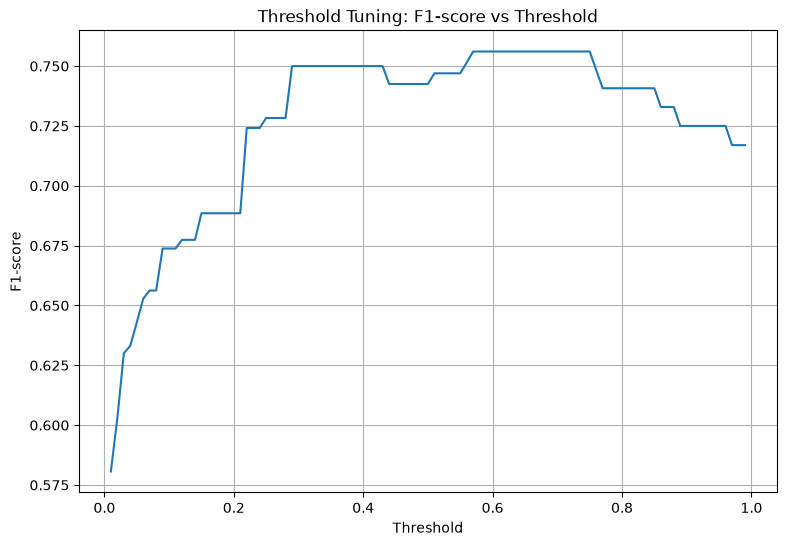

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"]
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold Tuning: F1-score vs Threshold")

plt.grid()

plt.show()

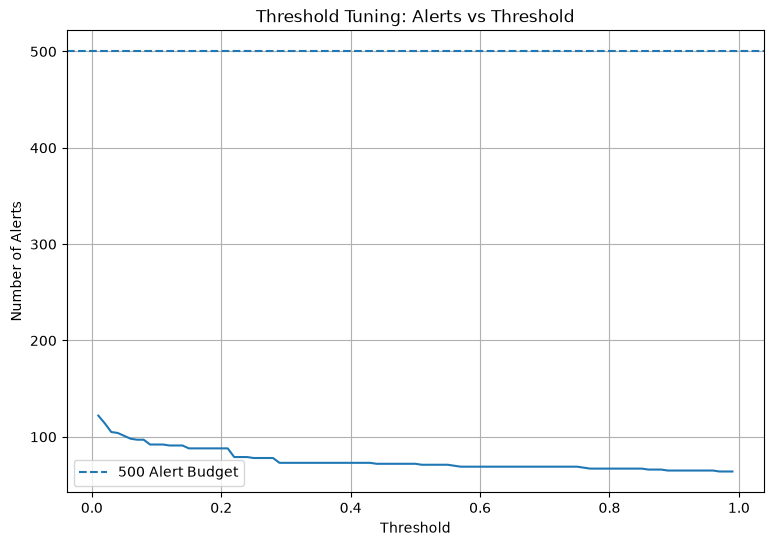

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["alerts"]
)

plt.axhline(
    500,
    linestyle="--",
    label="500 Alert Budget"
)

plt.xlabel("Threshold")
plt.ylabel("Number of Alerts")
plt.title("Threshold Tuning: Alerts vs Threshold")

plt.legend()
plt.grid()

plt.show()

In [ ]:
budget_results = threshold_results[
    threshold_results["alerts"] <= 500
].copy()
best_threshold = budget_results.loc[
    budget_results["recall"].idxmax()
]


In [ ]:

print("   THRESHOLD TUNING RESULTS")


print(f"Best threshold : {best_threshold['threshold']:.2f}")
print(f"Precision      : {best_threshold['precision']:.4f}")
print(f"Recall         : {best_threshold['recall']:.4f}")
print(f"F1-score       : {best_threshold['f1']:.4f}")
print(f"Alerts         : {best_threshold['alerts']}")
print(f"True Negatives : {best_threshold['TN']}")
print(f"False Positives: {best_threshold['FP']}")
print(f"False Negatives: {best_threshold['FN']}")
print(f"True Positives : {best_threshold['TP']}")
print(f"PR-AUC         : {pr_auc:.4f}")



   THRESHOLD TUNING RESULTS
Best threshold : 0.01
Precision      : 0.5164
Recall         : 0.6632
F1-score       : 0.5806
Alerts         : 122.0
True Negatives : 56592.0
False Positives: 59.0
False Negatives: 32.0
True Positives : 63.0
PR-AUC         : 0.6234


In [ ]:
comparison = pd.DataFrame([
    {
        "Setting": "Default threshold",
        "Threshold": 0.50,
        "Precision": default_result["precision"],
        "Recall": default_result["recall"],
        "F1": default_result["f1"],
        "Alerts": default_result["alerts"]
    },
    {
        "Setting": "Tuned threshold",
        "Threshold": best_threshold["threshold"],
        "Precision": best_threshold["precision"],
        "Recall": best_threshold["recall"],
        "F1": best_threshold["f1"],
        "Alerts": best_threshold["alerts"]
    }
])

comparison

,Setting,Threshold,Precision,Recall,F1,Alerts
0,Default threshold,0.50,0.861111,0.652632,0.742515,72.0
1,Tuned threshold,0.01,0.516393,0.663158,0.580645,122.0


In [ ]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

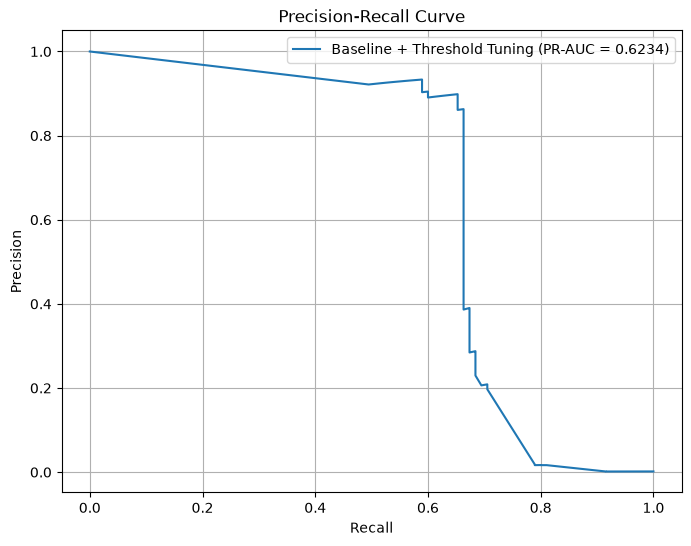

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Baseline + Threshold Tuning (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid()

plt.show()